## Overview

for different models

Plot loss vs epochs through training process on same season

----
## Data:

-2D Space - Timeseries

-predicting 1 feature out of 7 variables

-Forecasting 1 timestep (not the following)

-------
Peter Resch, 7.6.

In [ ]:
from __future__ import print_function, division   # Ensures Python3 printing & division standard
import pandas as pd 
from pandas import Series, DataFrame 
from matplotlib import pyplot as plt
import numpy as np
import os
from pathlib import Path

import seaborn as sns

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split

from matplotlib.lines import Line2D
import xarray as xr

from my_dataloader_module import TimeseriesDatasetPipeline, TimeseriesPyTorchDataset

rSeed=42

SavePlots = False

## Loading Data

In [26]:
working_dir="models"#"../../../datasets/small_grid"
image_folder="images"
!cd {working_dir} && ls

GRU				    losses_cnn_lstm_recent_spring.csv
losses_cnn_gru_combined_autumn.csv  losses_cnn_lstm_recent_summer.csv
losses_cnn_gru_combined_spring.csv  losses_cnn_lstm_recent_winter.csv
losses_cnn_gru_combined_summer.csv  losses_cnn_lstm_tuned_combined_autumn.csv
losses_cnn_gru_combined_winter.csv  losses_cnn_lstm_tuned_combined_spring.csv
losses_cnn_gru_past_autumn.csv	    losses_cnn_lstm_tuned_combined_summer.csv
losses_cnn_gru_past_spring.csv	    losses_cnn_lstm_tuned_combined_winter.csv
losses_cnn_gru_past_summer.csv	    losses_cnn_lstm_tuned_recent_autumn.csv
losses_cnn_gru_past_winter.csv	    losses_cnn_lstm_tuned_recent_spring.csv
losses_cnn_gru_recent_autumn.csv    losses_cnn_lstm_tuned_recent_summer.csv
losses_cnn_gru_recent_spring.csv    losses_cnn_lstm_tuned_recent_winter.csv
losses_cnn_gru_recent_summer.csv    LSTM
losses_cnn_gru_recent_winter.csv    LSTM-HPT
losses_cnn_lstm_recent_autumn.csv


In [27]:
seasons={"spring": "MAM", "summer": "JJA", "autumn": "SON", "winter": "DJF"}

filelist = [p.name for p in Path(working_dir).iterdir() if p.is_file()]
filelist = [f for f in filelist if f.endswith('.csv')]
filelist.sort()
print(filelist)

['losses_cnn_gru_combined_autumn.csv', 'losses_cnn_gru_combined_spring.csv', 'losses_cnn_gru_combined_summer.csv', 'losses_cnn_gru_combined_winter.csv', 'losses_cnn_gru_past_autumn.csv', 'losses_cnn_gru_past_spring.csv', 'losses_cnn_gru_past_summer.csv', 'losses_cnn_gru_past_winter.csv', 'losses_cnn_gru_recent_autumn.csv', 'losses_cnn_gru_recent_spring.csv', 'losses_cnn_gru_recent_summer.csv', 'losses_cnn_gru_recent_winter.csv', 'losses_cnn_lstm_recent_autumn.csv', 'losses_cnn_lstm_recent_spring.csv', 'losses_cnn_lstm_recent_summer.csv', 'losses_cnn_lstm_recent_winter.csv', 'losses_cnn_lstm_tuned_combined_autumn.csv', 'losses_cnn_lstm_tuned_combined_spring.csv', 'losses_cnn_lstm_tuned_combined_summer.csv', 'losses_cnn_lstm_tuned_combined_winter.csv', 'losses_cnn_lstm_tuned_recent_autumn.csv', 'losses_cnn_lstm_tuned_recent_spring.csv', 'losses_cnn_lstm_tuned_recent_summer.csv', 'losses_cnn_lstm_tuned_recent_winter.csv']


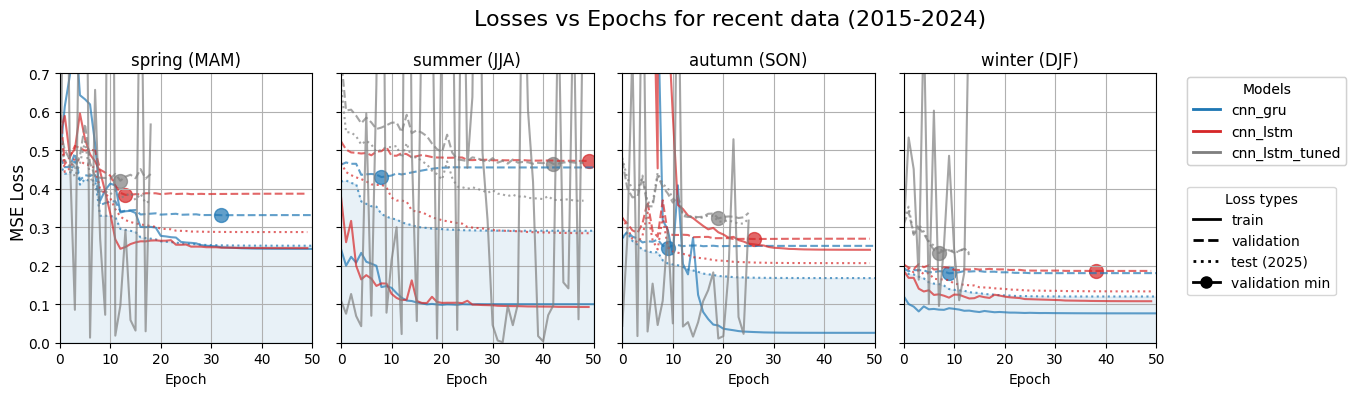

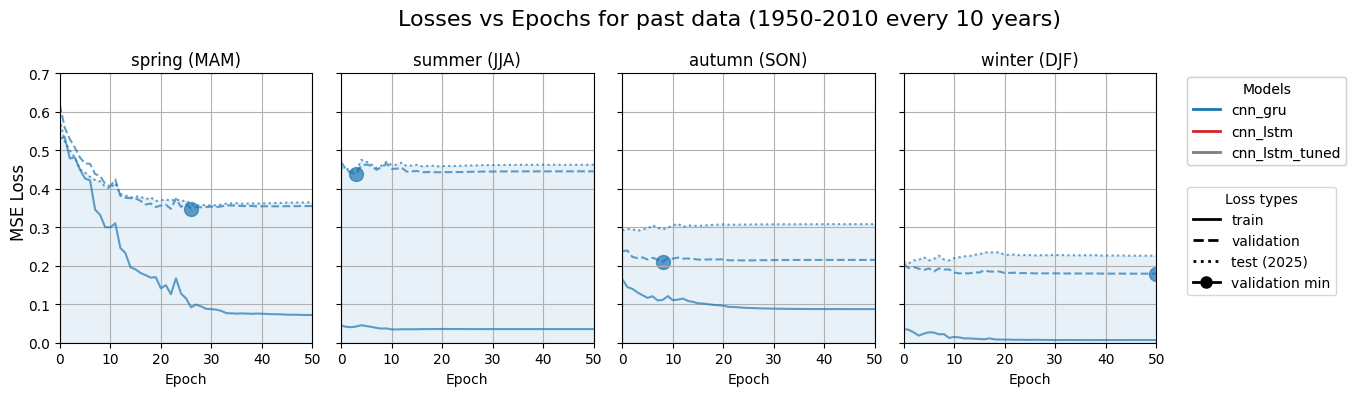

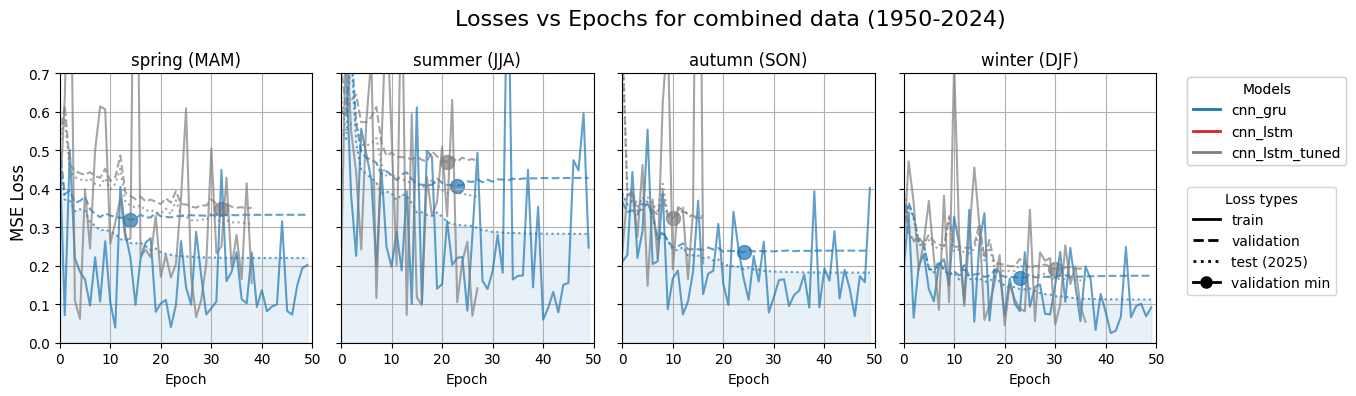

In [ ]:
#plotting losses vs epochs for all models for all seasons for recent, past and combined data
time={"recent": "2015-2024", "past": "1950-2010 every 10 years", "combined": "1950-2024"}
models = {
    "gru": "tab:blue",
    "lstm": "tab:red",
    "lstm_tuned": "tab:gray",
}
loss_types = {"Train Loss": "-", "Validate Loss": "--", "Test Loss": ":"}
alpha = 0.7
epochs_to_plot = 51

for t, description in time.items():
    fig,ax=plt.subplots(1,4,figsize=(15, 4), sharey=True)
    fig.subplots_adjust(right=0.82, wspace=0.1)
    for i, season in enumerate(seasons.keys()):
        for model in models.keys():
            filename=f"losses_cnn_{model}_{t}_{season}.csv"
            if filename in filelist:
                df = pd.read_csv(os.path.join(working_dir, filename))
                #only read first 50 epochs
                df = df[:epochs_to_plot]
                #print(df.head())
                ax[i].plot(df['Train Loss'], label=f"{model} train", color=models.get(model), linestyle=loss_types.get("Train Loss"),alpha=alpha)
                ax[i].plot(df['Validate Loss'], label=f"{model} val", color=models.get(model), linestyle=loss_types.get("Validate Loss"),alpha=alpha)
                ax[i].plot(df['Test Loss'], label=f"{model} test", color=models.get(model), linestyle=loss_types.get("Test Loss"),alpha=alpha)
                ax[i].scatter(df['Validate Loss'].idxmin(), df['Validate Loss'].min(), color=models.get(model), marker='o', s=100, label=f"{model} val min", alpha=alpha)
                #fill underneath the cnn_gru test loss curve
                if "gru" in model:
                    ax[i].fill_between(df.index, df['Test Loss'], alpha=0.1, color=models.get(model))
        ax[i].set_title(f"{season} ({seasons[season]})")
        ax[i].set_xlabel("Epoch")
        ax[i].set_ylim(0, 0.7)
        ax[i].set_xlim(0, epochs_to_plot-1)
        ax[i].grid()
    fig.supylabel("MSE Loss")
    model_handles = [Line2D([0], [0], color=models[name], lw=2, label=f"cnn_{name}") for name in models.keys()]
    loss_handles = [
        Line2D([0], [0], color="black", lw=2, linestyle=loss_types["Train Loss"], label="train"),
        Line2D([0], [0], color="black", lw=2, linestyle=loss_types["Validate Loss"], label="validation"),
        Line2D([0], [0], color="black", lw=2, linestyle=loss_types["Test Loss"], label="test (2025)"),
        Line2D([0], [0], color="black", lw=2, marker='o', markersize=8, label="validation min")
    ]
    legend_models = fig.legend(handles=model_handles, title="Models", loc="center left", bbox_to_anchor=(0.8, 0.7))
    fig.add_artist(legend_models)
    fig.suptitle(f"Losses vs Epochs for {t} data ({description})", fontsize=16)
    fig.legend(handles=loss_handles, title="Loss types", loc="center left", bbox_to_anchor=(0.8, 0.4))
    fig.tight_layout(rect=[0, 0, 0.8, 1])

    if False:
        plt.savefig(os.path.join(image_folder, f"losses_vs_epochs_{t}+LSTM-HPT.png"))
